# Ps2 Problem 2
Training two neural nets on `turbulent_radiative_layer_2D` from The Well.
Most code done with claude claudi.ai


1a) My architecture predicts a future state from prior states for turbulent radiative mixing using data from the well. This is a 2d grid with periodic boundary conditions along one axis and no gradient conditon on the other. This is basically just what is done in the well tutorial but with a symmetry condition in the architecture for testing how well that performs. 

1b) A normal conditon one would like to consider is energy or momentum conservation but with radiative cooling and mixing it's actually not straight forward to do this (and momentum conservation is only in one direction because of the boundasries). So I am enforcing total mass conservation because mass doesn't just disappear

2a) My architecture is a 2d conv neural net but with the forward pass being forced to keep the total mass across the entire grid constant.

2b) This symmetry is preserved because the prediciton is based on prior steps so I am never predicting total mass only changes in mass --> total changes in mass have no change

In [1]:
!pip install the_well --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, SubsetRandomSampler
from the_well.data import WellDataset

DATASET  = 'turbulent_radiative_layer_2D'
DEVICE   =  'cpu'
BATCH    = 8
T        = 2
N_FIELDS = 4   # rho, P, vx, vy
EPOCHS   = 5
LR       = 3e-4


## 1. Data Loading 

In [3]:
BASE_PATH = './datasets'

class WellWrapper(torch.utils.data.Dataset):
    def __init__(self, split):
        self.ds = WellDataset(
            well_base_path='./datasets/' + BASE_PATH,  # matches example: well_download creates datasets/ subdir inside base_path
            well_dataset_name=DATASET,
            well_split_name=split,
            n_steps_input=T,
            n_steps_output=1,
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        x = torch.tensor(sample['input_fields'],  dtype=torch.float32)  # (T, H, W, F)
        y = torch.tensor(sample['output_fields'], dtype=torch.float32)  # (1, H, W, F)
        return x, y


def limited_loader(split, n):
    ds  = WellWrapper(split)
    idx = np.random.choice(len(ds), min(n, len(ds)), replace=False)
    return DataLoader(ds, batch_size=BATCH, sampler=SubsetRandomSampler(idx), num_workers=0)

In [4]:
train_dl = limited_loader('train', n=200)
val_dl   = limited_loader('valid', n=50)
test_dl  = limited_loader('test',  n=50)

# Compute per-field mean and std from a small subset of training data.
# Reuse the WellWrapper already created inside train_dl to avoid a duplicate dataset open.
train_ds = train_dl.dataset
xs = torch.stack([torch.tensor(train_ds.ds[i]['input_fields'], dtype=torch.float32)
                  for i in range(0, 500, 50)])   # (10, T, H, W, F)
n_fields = xs.shape[-1]   # 4: rho, P, vx, vy
mu    = xs.reshape(-1, n_fields).mean(dim=0)     # (F,)
sigma = xs.reshape(-1, n_fields).std(dim=0)      # (F,)
print(f'mu:    {mu}')
print(f'sigma: {sigma}')

# Sanity check shapes
x, y = next(iter(train_dl))
print(f'Raw input shape:  {x.shape}  -- (B, T, H, W, F)')
print(f'Raw target shape: {y.shape}  -- (B, 1, H, W, F)')

/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/4289771807.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xs = torch.stack([torch.tensor(train_ds.ds[i]['input_fields'], dtype=torch.float32)
/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/552326110.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(sample['input_fields'],  dtype=torch.float32)  # (T, H, W, F)
/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/552326110.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

mu:    tensor([ 3.4949e+01,  8.9715e-01,  7.8890e-03, -4.7375e-02])
sigma: tensor([43.4067,  0.0985,  0.0483,  0.0687])
Raw input shape:  torch.Size([8, 2, 128, 384, 4])  -- (B, T, H, W, F)
Raw target shape: torch.Size([8, 1, 128, 384, 4])  -- (B, 1, H, W, F)


## 2. Preprocessing and Training Utilities

After reshaping, the channel layout of `x_in` is:
```
[ rho@t=0, P@t=0, vx@t=0, vy@t=0,  rho@t=1, P@t=1, vx@t=1, vy@t=1 ]
   ch 0     ch 1   ch 2    ch 3      ch 4     ch 5    ch 6     ch 7
```


In [5]:
def preprocess(x):
    """Normalise per field. x can be (B, T, H, W, F) or (B, 1, H, W, F)."""
    shape  = (1,) * (x.ndim - 1) + (-1,)
    mu_    = mu.to(x.device).reshape(shape)
    sigma_ = sigma.to(x.device).reshape(shape)
    return (x - mu_) / (sigma_ + 1e-8)


def mass_error(pred, x_in):
    """Normalised absolute change in total rho between prediction and most recent input frame.
    FIX 3: was x_in[:, 0] (oldest frame). Now uses x_in[:, (T-1)*n_fields] (most recent).
    """
    rho_pred = pred[:, 0]
    rho_n    = x_in[:, (T - 1) * n_fields]   # FIX 3
    return ((rho_pred - rho_n).sum((-1, -2)).abs() /
             rho_n.sum((-1, -2)).abs()).mean().item()


def run_epoch(model, loader, optimiser=None):
    model.train() if optimiser else model.eval()
    total_loss, total_merr, n = 0, 0, 0
    ctx = torch.enable_grad() if optimiser else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            x = preprocess(x)
            y = preprocess(y)
            B, Ti, H, W, nF = x.shape
            x_in = x.permute(0, 1, 4, 2, 3).reshape(B, Ti * nF, H, W)  # (B, T*F, H, W)
            y_in = y.squeeze(1).permute(0, 3, 1, 2)                     # (B, F, H, W)
            pred = model(x_in)
            loss = F.mse_loss(pred, y_in)
            if optimiser:
                optimiser.zero_grad(); loss.backward(); optimiser.step()
            total_loss += loss.item()
            total_merr += mass_error(pred, x_in)
            n += 1
    return total_loss / n, total_merr / n

## 3. Models

**Conservation approach**: predicts a zero-mean delta on rho (guaranteeing exact mass conservation) plus P, vx, vy freely. No physical constants, denorm/renorm, or boundary conditions needed.

In [6]:
class Encoder(nn.Module):
    def __init__(self, T=2, C=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(T * N_FIELDS, C, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv2d(C,            C, kernel_size=3, padding=1), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class BaselineModel(nn.Module):
    def __init__(self, T=2, C=16):
        super().__init__()
        self.encoder = Encoder(T, C)
        self.head    = nn.Conv2d(C, N_FIELDS, kernel_size=1)

    def forward(self, x):
        return self.head(self.encoder(x))


class ConservationModel(nn.Module):
    def __init__(self, T=2, C=16):
        super().__init__()
        self.T          = T
        self.encoder    = Encoder(T, C)
        self.field_head = nn.Conv2d(C, N_FIELDS, kernel_size=1)  # predicts (delta_rho, P, vx, vy)

    def forward(self, x):
        feat = self.encoder(x)
        out  = self.field_head(feat)          # (B, 4, H, W)

        # Most recent rho in normalised space
        rho_ch    = (self.T - 1) * N_FIELDS
        rho_n     = x[:, rho_ch : rho_ch + 1]

        # Zero-mean delta: spatial sum is exactly zero → total mass conserved
        delta_rho = out[:, 0:1]
        delta_rho = delta_rho - delta_rho.mean((-1, -2), keepdim=True)
        rho_pred  = rho_n + delta_rho

        return torch.cat([rho_pred, out[:, 1:]], dim=1)   # (B, 4, H, W)

## 4. Train Both Models

In [7]:
models = {
    'Baseline':     BaselineModel(T).to(DEVICE),
    'Conservation': ConservationModel(T).to(DEVICE),
}
history = {name: {'val_loss': [], 'val_mass_err': []} for name in models}

for name, model in models.items():
    print(f'\nTraining: {name}')
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(EPOCHS):
        tr_loss, tr_merr = run_epoch(model, train_dl, opt)
        vl_loss, vl_merr = run_epoch(model, val_dl)
        history[name]['val_loss'].append(vl_loss)
        history[name]['val_mass_err'].append(vl_merr)
        print(f'  epoch {epoch+1:02d}/{EPOCHS}  '
              f'train loss {tr_loss:.4f}  '
              f'val loss {vl_loss:.4f}  '
              f'mass err {vl_merr:.3e}')


Training: Baseline


/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/552326110.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(sample['input_fields'],  dtype=torch.float32)  # (T, H, W, F)
/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/552326110.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(sample['output_fields'], dtype=torch.float32)  # (1, H, W, F)


  epoch 01/5  train loss 0.6288  val loss 0.5159  mass err 2.500e+01
  epoch 02/5  train loss 0.4019  val loss 0.3317  mass err 1.335e+01
  epoch 03/5  train loss 0.2490  val loss 0.2016  mass err 1.362e+01
  epoch 04/5  train loss 0.1814  val loss 0.1571  mass err 1.135e+01
  epoch 05/5  train loss 0.1505  val loss 0.1414  mass err 1.337e+01

Training: Conservation
  epoch 01/5  train loss 0.4789  val loss 0.4036  mass err 1.758e-07
  epoch 02/5  train loss 0.3272  val loss 0.2521  mass err 1.171e-07
  epoch 03/5  train loss 0.1979  val loss 0.1615  mass err 1.961e-07
  epoch 04/5  train loss 0.1284  val loss 0.1167  mass err 2.605e-07
  epoch 05/5  train loss 0.1103  val loss 0.1041  mass err 1.852e-07


## 5. Results

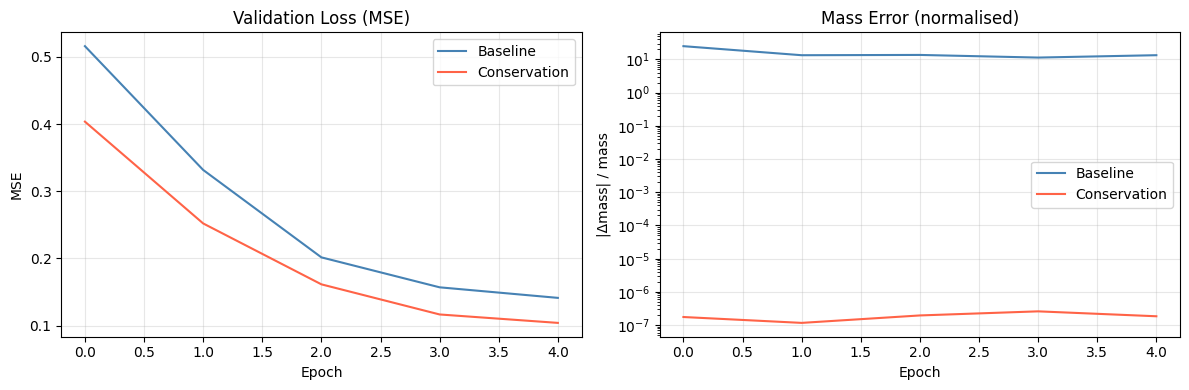


Model             Val Loss   Mass Error
----------------------------------------
Baseline            0.1414    1.337e+01
Conservation        0.1041    1.852e-07


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = {'Baseline': 'steelblue', 'Conservation': 'tomato'}
for name, h in history.items():
    ax1.plot(h['val_loss'],     label=name, color=colors[name])
    ax2.plot(h['val_mass_err'], label=name, color=colors[name])
ax1.set(title='Validation Loss (MSE)', xlabel='Epoch', ylabel='MSE')
ax2.set(title='Mass Error (normalised)', xlabel='Epoch', ylabel='|\u0394mass| / mass', yscale='log')
for ax in (ax1, ax2):
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Model':<15} {'Val Loss':>10} {'Mass Error':>12}")
print('-' * 40)
for name, h in history.items():
    print(f"{name:<15} {h['val_loss'][-1]:>10.4f} {h['val_mass_err'][-1]:>12.3e}")

In [9]:
# Per-field loss breakdown
FIELD_NAMES = ['rho', 'P', 'vx', 'vy']

@torch.no_grad()
def field_losses(model, loader):
    losses = {f: 0 for f in FIELD_NAMES}
    n = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x = preprocess(x)
        y = preprocess(y)
        B, Ti, H, W, nF = x.shape
        x_in = x.permute(0, 1, 4, 2, 3).reshape(B, Ti * nF, H, W)
        y_in = y.squeeze(1).permute(0, 3, 1, 2)
        pred = model(x_in)
        for i, f in enumerate(FIELD_NAMES):
            losses[f] += F.mse_loss(pred[:, i], y_in[:, i]).item()
        n += 1
    return {f: v/n for f, v in losses.items()}

for name, model in models.items():
    print(f'{name}: {field_losses(model, val_dl)}')

/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/552326110.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(sample['input_fields'],  dtype=torch.float32)  # (T, H, W, F)
/var/folders/tv/kyx732ws4x3_n0t0mqp49s6m0000gq/T/ipykernel_16565/552326110.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(sample['output_fields'], dtype=torch.float32)  # (1, H, W, F)


Baseline: {'rho': 0.11899459681340627, 'P': 0.22247204557061195, 'vx': 0.15256712692124502, 'vy': 0.10206053884966033}
Conservation: {'rho': 0.07738827913999557, 'P': 0.12370583681123597, 'vx': 0.1368009884442602, 'vy': 0.09642379518066134}


The symmetry architecture actually does much much better. But i wonder 